# Lagged Predictions of Next Week Alcohol Use for Precision Mental

Health Support

Kendra Wyant (Department of Psychology, University of Wisconsin-Madison)  
Jiachen (Coco) Yu (Department of Psychology, University of Wisconsin-Madison)  
Gaylen E. Fronk (Department of Psychology, University of Wisconsin-Madison)  
John J. Curtin (Department of Psychology, University of Wisconsin-Madison)  
June 5, 2024

This study found some pretty cool results that have both high impact and important clinical implications. For example …

In [ ]:
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(source("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true"))
suppressPackageStartupMessages(library(tidyposterior))
library(kableExtra)


Attaching package: 'kableExtra'

The following object is masked from 'package:dplyr':

    group_rows

In [ ]:
test_metrics_0 <- read_csv(file.path(path_models_lag, 
                                        "test_metrics_1week_0_v2_nested.csv"), 
                              col_types = cols()) |> 
  filter(.metric == "roc_auc") |> 
  select(outer_split_num, "lag0" = .estimate)

test_metrics_24 <- read_csv(file.path(path_models_lag, 
                                       "test_metrics_1week_24_v2_nested.csv"),
                             col_types = cols()) |> 
  filter(.metric == "roc_auc") |> 
  select(outer_split_num, "lag24" = .estimate)

test_metrics_72 <- read_csv(file.path(path_models_lag, 
                                        "test_metrics_1week_72_v2_nested.csv"),
                              col_types = cols()) |> 
  filter(.metric == "roc_auc") |> 
  select(outer_split_num, "lag72" = .estimate)

test_metrics_168 <- read_csv(file.path(path_models_lag, 
                                        "test_metrics_1week_168_v2_nested.csv"), 
                              col_types = cols()) |> 
  filter(.metric == "roc_auc") |> 
  select(outer_split_num, "lag168" = .estimate)

test_metrics_336 <- read_csv(file.path(path_models_lag, 
                                       "test_metrics_1week_336_v2_nested.csv"),
                             col_types = cols()) |> 
  filter(.metric == "roc_auc") |> 
  select(outer_split_num, "lag336" = .estimate)

test_metrics_all <- test_metrics_0 |> 
  left_join(test_metrics_24, by = c("outer_split_num")) |> 
  left_join(test_metrics_72, by = c("outer_split_num")) |>
  left_join(test_metrics_168, by = c("outer_split_num")) |>
  left_join(test_metrics_336, by = c("outer_split_num")) |> 
  mutate(fold_num = rep(1:10, 3),
         repeat_num = c(rep(1, 10), rep(2, 10), rep(3, 10))) |> 
  select(-outer_split_num)

pp_dem <- read_csv(file.path(path_models_lag, "pp_dem_0.csv"), col_types = cols()) |> 
  mutate(lag = 0) |> 
  bind_rows(read_csv(file.path(path_models_lag, "pp_dem_24.csv"), col_types = cols()) |> 
  mutate(lag = 24)) |> 
  bind_rows(read_csv(file.path(path_models_lag, "pp_dem_72.csv"), col_types = cols()) |> 
  mutate(lag = 72)) |> 
  bind_rows(read_csv(file.path(path_models_lag, "pp_dem_168.csv"), col_types = cols()) |> 
  mutate(lag = 168)) |> 
  bind_rows(read_csv(file.path(path_models_lag, "pp_dem_336.csv"), col_types = cols()) |> 
  mutate(lag = 336))

pp_dem_contrast <- read_csv(file.path(path_models_lag, "pp_dem_contrast_0.csv"), col_types = cols()) |> 
  mutate(lag = 0) |> 
  bind_rows(read_csv(file.path(path_models_lag, "pp_dem_contrast_24.csv"), col_types = cols()) |> 
  mutate(lag = 24)) |> 
  bind_rows(read_csv(file.path(path_models_lag, "pp_dem_contrast_72.csv"), col_types = cols()) |> 
  mutate(lag = 72)) |> 
  bind_rows(read_csv(file.path(path_models_lag, "pp_dem_contrast_168.csv"), col_types = cols()) |> 
  mutate(lag = 168)) |> 
  bind_rows(read_csv(file.path(path_models_lag, "pp_dem_contrast_336.csv"), col_types = cols()) |> 
  mutate(lag = 336))

pp_dem_contrast <- pp_dem_contrast |> 
  group_by(contrast) |> 
  summarise(across(probability:upper, median))

In [ ]:
disposition <- read_csv(file.path(path_processed, "disposition.csv"), 
                        col_types = "ccDDcccccccccc")

screen <- read_csv(file.path(path_shared, "screen.csv"), 
                   col_types = cols()) |>
  filter(subid %in% subset(disposition, analysis == "yes")$subid) |> 
  mutate(across(dsm5_1:dsm5_11, ~ recode(., "No" = 0, "Yes" = 1))) |>  
  rowwise() |>  
  mutate(dsm5_total = sum(c(dsm5_1, dsm5_2, dsm5_3, dsm5_4, dsm5_5, dsm5_6, dsm5_7, 
                              dsm5_8, dsm5_9, dsm5_10, dsm5_11))) |>  
  ungroup()

lapses <- read_csv(file.path(path_shared, "lapses.csv"), col_types = cols()) |>
  filter(exclude == FALSE)

# Calcs to make df for table 1 (demographics and clinical characteristics)
n_total <- 151

dem <- screen |>
  summarise(mean = as.character(round(mean(dem_1, na.rm = TRUE), 1)),
            SD = as.character(round(sd(dem_1, na.rm = TRUE), 1)),
            min = as.character(min(dem_1, na.rm = TRUE)),
            max = as.character(max(dem_1, na.rm = TRUE))) |>
  mutate(var = "Age",
         n = as.numeric(""),
         perc = as.numeric("")) |>
  select(var, n, perc, everything()) |>
  full_join(screen |>
  select(var = dem_2) |>
  group_by(var) |>
  summarise(n = n()) |>
  mutate(perc = (n / sum(n)) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = dem_3) |>
  mutate(var = fct_relevel(factor(var,
                         c("American Indian/Alaska Native", "Asian", "Black/African American",
                           "White/Caucasian", "Other/Multiracial")))) |>
  group_by(var) |>
  summarise(n = n()) |>
  mutate(perc = (n / sum(n)) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = dem_4) |>
  mutate(var = case_when(var == "No, I am not of Hispanic, Latino, or Spanish origin" ~ "No",
                         TRUE ~ "Yes"),
         var = fct_relevel(factor(var, c("Yes", "No")))) |>
  group_by(var) |>
  summarise(n = n()) |>
  mutate(perc = (n / sum(n)) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = dem_5) |>
  mutate(var = fct_relevel(factor(var,
                         c("Less than high school or GED degree", "High school or GED",
                           "Some college", "2-Year degree", "College degree", "Advanced degree")))) |>
  group_by(var) |>
  summarise(n = n()) |>
  mutate(perc = (n / sum(n)) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = dem_6, dem_6_1) |>
  mutate(var = case_when(dem_6_1 == "Full-time" ~ "Employed full-time",
                         dem_6_1 == "Part-time" ~ "Employed part-time",
                         TRUE ~ var)) |>
  mutate(var = fct_relevel(factor(var,
                         c("Employed full-time", "Employed part-time", "Full-time student",
                           "Homemaker", "Disabled", "Retired", "Unemployed",
                           "Temporarily laid off, sick leave, or maternity leave",
                           "Other, not otherwise specified")))) |>
  group_by(var) |>
  summarise(n = n()) |>
  mutate(perc = (n / sum(n)) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  summarise(mean = format(round(mean(dem_7, na.rm = TRUE), 0), big.mark = ","),
            SD = format(round(sd(dem_7, na.rm = TRUE), 0), big.mark = ","),
            min =format(round(min(dem_7, na.rm = TRUE), 0), big.mark = ","),
            max = format(round(max(dem_7, na.rm = TRUE), 0), scientific = FALSE, big.mark = ",")) |>
  mutate(var = "Personal Income",
        n = as.numeric(""),
        perc = as.numeric(""),
        mean = str_c("$", as.character(mean)),
        SD = str_c("$", as.character(SD)),
        min = str_c("$", as.character(min)),
        max = as.character(max)) |>
  select(var, n, perc, everything()), by = c("var", "n", "perc", "mean", "SD", "min", "max")) |>
  full_join(screen |>
  select(var = dem_8) |>
  mutate(var = case_when(var == "Never Married" ~ "Never married",
                         TRUE ~ var)) |>
  mutate(var = fct_relevel(factor(var,
                         c("Never married", "Married", "Divorced", "Separated",
                           "Widowed")))) |>
  group_by(var) |>
  summarise(n = n()) |>
  mutate(perc = (n / sum(n)) * 100), by = c("var", "n", "perc"))

auh <- screen |>
  summarise(mean = mean(auh_1, na.rm = TRUE),
            SD = sd(auh_1, na.rm = TRUE),
            min = min(auh_1, na.rm = TRUE),
            max = max(auh_1, na.rm = TRUE)) |>
  mutate(var = "Age of first drink",
        n = as.numeric(""),
        perc = as.numeric("")) |>
  select(var, n, perc, everything()) |>
  full_join(screen |>
  summarise(mean = mean(auh_2, na.rm = TRUE),
            SD = sd(auh_2, na.rm = TRUE),
            min = min(auh_2, na.rm = TRUE),
            max = max(auh_2, na.rm = TRUE)) |>
  mutate(var = "Age of regular drinking",
        n = as.numeric(""),
        perc = as.numeric("")) |>
  select(var, n, perc, everything()), by = c("var", "n", "perc", "mean", "SD",
                                             "min", "max")) |>
  full_join(screen |>
  summarise(mean = mean(auh_3, na.rm = TRUE),
            SD = sd(auh_3, na.rm = TRUE),
            min = min(auh_3, na.rm = TRUE),
            max = max(auh_3, na.rm = TRUE)) |>
  mutate(var = "Age at which drinking became problematic",
        n = as.numeric(""),
        perc = as.numeric("")) |>
  select(var, n, perc, everything()), by = c("var", "n", "perc", "mean", "SD",
                                             "min", "max")) |>
  full_join(screen |>
  summarise(mean = mean(auh_4, na.rm = TRUE),
            SD = sd(auh_4, na.rm = TRUE),
            min = min(auh_4, na.rm = TRUE),
            max = max(auh_4, na.rm = TRUE)) |>
  mutate(var = "Age of first quit attempt",
        n = as.numeric(""),
        perc = as.numeric("")) |>
  select(var, n, perc, everything()), by = c("var", "n", "perc", "mean", "SD",
                                             "min", "max")) |>
  full_join(screen |>
  # filter out 2 people with 100 and 365 reported quit attempts - will make footnote in table
  filter(auh_5 < 100) |>
  summarise(mean = mean(auh_5, na.rm = TRUE),
            SD = sd(auh_5, na.rm = TRUE),
            min = min(auh_5, na.rm = TRUE),
            max = max(auh_5, na.rm = TRUE)) |>
  mutate(var = "Number of Quit Attempts*",
        n = as.numeric(""),
        perc = as.numeric("")) |>
  select(var, n, perc, everything()), by = c("var", "n", "perc", "mean", "SD",
                                             "min", "max")) |>
  full_join(screen |>
  select(var = auh_6_1) |>
  mutate(var = case_when(var == "Long-Term Residential Treatment (more than 6 months)" ~ "Long-term residential (6+ months)",
                         TRUE ~ var)) |>
  group_by(var) |>
  drop_na() |>
  summarise(n = n()) |>
  mutate(perc = (n / n_total) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = auh_6_2) |>
  mutate(var = case_when(var == "Short-Term Residential Treatment (less than 6 months)" ~ "Short-term residential (< 6 months)",
                         TRUE ~ var)) |>
  group_by(var) |>
  drop_na() |>
  summarise(n = n()) |>
  mutate(perc = (n / n_total) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = auh_6_3) |>
  mutate(var = case_when(var == "Outpatient Treatment" ~ "Outpatient",
                         TRUE ~ var)) |>
  group_by(var) |>
  drop_na() |>
  summarise(n = n()) |>
  mutate(perc = (n / n_total) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = auh_6_4) |>
  mutate(var = case_when(var == "Individual Counseling" ~ "Individual counseling",
                         TRUE ~ var)) |>
  group_by(var) |>
  drop_na() |>
  summarise(n = n()) |>
  mutate(perc = (n / n_total) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = auh_6_5) |>
  mutate(var = case_when(var == "Group Counseling" ~ "Group counseling",
                         TRUE ~ var)) |>
  group_by(var) |>
  drop_na() |>
  summarise(n = n()) |>
  mutate(perc = (n / n_total) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = auh_6_6) |>
  group_by(var) |>
  drop_na() |>
  summarise(n = n()) |>
  mutate(perc = (n / n_total) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = auh_6_7) |>
  group_by(var) |>
  drop_na() |>
  summarise(n = n()) |>
  mutate(perc = (n / n_total) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = auh_7) |>
  mutate(var = fct_relevel(factor(var, c("Yes", "No")))) |>
  group_by(var) |>
  summarise(n = n()) |>
  mutate(perc = (n / sum(n)) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  summarise(mean = mean(dsm5_total),
            SD = sd(dsm5_total),
            min = min(dsm5_total, na.rm = TRUE),
            max = max(dsm5_total, na.rm = TRUE)) |>
  mutate(var = "DSM-5 Alcohol Use Disorder Symptom Count",
        n = as.numeric(""),
        perc = as.numeric("")) |>
  select(var, n, perc, everything()), by = c("var", "n", "perc", "mean", "SD",
                                             "min", "max")) |>
  full_join(screen |>
  select(var = assist_2_1) |>
  filter(var != "Never" & !is.na(var)) |>
  mutate(var = "Tobacco products (cigarettes, chewing tobacco, cigars, etc.)") |>
  group_by(var) |>
  drop_na() |>
  summarise(n = n()) |>
  mutate(perc = (n / n_total) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = assist_2_2) |>
  filter(var != "Never" & !is.na(var)) |>
  mutate(var = "Cannabis (marijuana, pot, grass, hash, etc.)") |>
  group_by(var) |>
  drop_na() |>
  summarise(n = n()) |>
  mutate(perc = (n / n_total) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = assist_2_3) |>
  filter(var != "Never" & !is.na(var)) |>
  mutate(var = "Cocaine (coke, crack, etc.)") |>
  group_by(var) |>
  drop_na() |>
  summarise(n = n()) |>
  mutate(perc = (n / n_total) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = assist_2_4) |>
  filter(var != "Never" & !is.na(var)) |>
  mutate(var = "Amphetamine type stimulants (speed, diet pills, ecstasy, etc.)") |>
  group_by(var) |>
  drop_na() |>
  summarise(n = n()) |>
  mutate(perc = (n / n_total) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = assist_2_5) |>
  filter(var != "Never" & !is.na(var)) |>
  mutate(var = "Inhalants (nitrous, glue, petrol, paint thinner, etc.)") |>
  group_by(var) |>
  drop_na() |>
  summarise(n = n()) |>
  mutate(perc = (n / n_total) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = assist_2_6) |>
  filter(var != "Never" & !is.na(var)) |>
  mutate(var = "Sedatives or sleeping pills (Valium, Serepax, Rohypnol, etc.)") |>
  group_by(var) |>
  drop_na() |>
  summarise(n = n()) |>
  mutate(perc = (n / n_total) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = assist_2_7) |>
  filter(var != "Never" & !is.na(var)) |>
  mutate(var = "Hallucinogens (LSD, acid, mushrooms, PCP, Special K, etc.)") |>
  group_by(var) |>
  drop_na() |>
  summarise(n = n()) |>
  mutate(perc = (n / n_total) * 100), by = c("var", "n", "perc")) |>
  full_join(screen |>
  select(var = assist_2_8) |>
  filter(var != "Never" & !is.na(var)) |>
  mutate(var = "Opioids (heroin, morphine, methadone, codeine, etc.)") |>
  group_by(var) |>
  drop_na() |>
  summarise(n = n()) |>
  mutate(perc = (n / n_total) * 100), by = c("var", "n", "perc"))

lapses_per_subid <- screen |>
  select(subid) |>
  left_join(lapses |>
  janitor::tabyl(subid) |>
  select(-percent), by = "subid") |>
  mutate(n = if_else(is.na(n), 0, n),
         lapse = if_else(n > 0, "yes", "no"))

lapse_info <- lapses_per_subid |>
  group_by(lapse) |>
  rename(var = lapse) |>
  mutate(var = factor(var, levels = c("yes", "no"), labels = c("Yes", "No"))) |>
  summarise(n = n()) |>
  mutate(perc = (n / n_total) * 100,
         mean = NA_real_,
         SD = NA_real_,
         min = NA_real_,
         max = NA_real_) |>
  full_join(lapses_per_subid |>
  summarise(mean = mean(n),
            SD = sd(n),
            min = min(n),
            max = max(n)) |>
  mutate(var = "Number of reported lapses"),
  by = c("var", "mean", "SD", "min", "max"))

# Introduction

Precision medicine has been a goal in healthcare for over half a century \[@derubeisHistoryCurrentStatus2019\]. Today, this approach is also applied to chronic mental health conditions, like substance use disorders (i.e., precision mental health). Precision mental health uses individual characteristics to guide initial treatment matching and adaptive continuing care over time. It requires dense, long-term monitoring of symptoms and related states, for interventions to be tailored to an individual’s needs and preferences at any given moment \[@bickmanAchievingPrecisionMental2016a\]. Essentially, it aims to identify both *when* and *how* to intervene.

Using algorithms to time (*when*) and select personalized interventions (*how*) for substance use may now be possible, thanks to personal sensing and high-dimensional machine learning algorithms. Personal sensing allows for frequent, longitudinal monitoring of individuals’ affect, behavior, and cognitions in their day-to-day lives \[@mohrPersonalSensingUnderstanding2017\]. These data can then be used as inputs for machine learning algorithms to predict the probability of specific outcomes (e.g., lapse risk) and identify the top features contributing to those predictions.

Ecological momentary assessment (EMA) may be particularly well-suited for these algorithms. It offers momentary subjective insight into constructs that can be easily mapped onto modular forms of treatment, such as the relapse prevention model \[@marlattRelapsePreventionMaintenance1985; @witkiewitzRelapsePreventionAlcohol2004\]. EMA also appears to be well tolerated by individuals with substance use disorders \[@wyantAcceptabilityPersonalSensing2023\]. Thus, it can serve as an important signal for predicting substance use outcomes and interpreting clinically relevant features over a sustained period.

Promising preliminary work suggests it is possible to build EMA models that predict immediate lapses back to substance use \[@waltersUsingMachineLearning2021; @baeMobilePhoneSensors2018; @soysterPooledPersonspecificMachine2022; @chihPredictiveModelingAddiction2014\]. In a previous study from our group, we demonstrated that we can do this very well. Model features were engineered from raw scores and longitudinal change in responses to 4X daily EMAs. EMA questions were designed to measure theoretically-implicated risk factors including past use, craving, past pleasant events, past and future risky situations, past and future stressful events, emotional valence and arousal, and self-efficacy \[for reviews, see @marlattRelapsePreventionMaintenance1985; @fronkStressAllostasisSubstance2020; @witkiewitzModelingComplexityPosttreatment2007\]. We showed that it was possible to predict immediate alcohol lapses within the next week, day, and hour with clinically meaningful accuracy - area under the receiver operating curves (auROCs) of 0.89, 0.90, and 0.93, respectively \[@wyantMachineLearningModels2023\]. We also characterized the relative importance of features contributing to these risk probabilities for specific individuals at specific moments in time. These models are well-suited for just-in-time adaptive interventions (JITAIs) integrated within an app to address these immediate risks.

However, some interventions take time to set up. For example, someone who has reported recent past alcohol use and low abstinence self-efficacy might be encouraged to attend a self-help meeting, plan an outing with important people in their life, or schedule an appointment with a therapist. These multimodal interventions (i.e., combined human and digital interventions) are not available 24/7. A *time-lagged* model with predictions shifted further into the future could provide patients with increased lead time to implement supports that might not be immediately available to them.

In this study, we compare the performance of one of our models from a previous study with models using increased lag time between predictions and outcomes. Specifically, we use the same EMA features as our immediate model and train new models to predict the probability of a lapse beginning one day (24 hours), three days (72 hours), one week (168 hours), or two weeks (336 hours) into the future. Our primary objective is to assess how model performance degrades with increasing lag time.

# Methods

## Transparency and Openness

We adhere to research transparency principles that are crucial for robust and replicable science. We preregistered our data analytic strategy. We reported how we determined the sample size, all data exclusions, all manipulations, and all study measures. We provide a transparency report in the supplement. Finally, our data, analysis scripts, annotated results, questionnaires, and other study materials are publicly available (<https://osf.io/xta67/>).

## Participants

We recruited 151 participants in early recovery (1-8 weeks of abstinence) from moderate to severe alcohol use disorder in Madison, Wisconsin, US for a three month longitudinal study. This sample size was determined based on traditional power analysis methods for logistic regression \[@hsiehSampleSizeTables1989\] because comparable approaches for machine learning models have not yet been validated. Participants were recruited through print and targeted digital advertisements and partnerships with treatment centers. We required participants:

1.  were age 18 or older,
2.  could write and read in English,
3.  had at least moderate AUD (\>= 4 self-reported DSM-5 symptoms),
4.  were abstinent from alcohol for 1-8 weeks, and
5.  were willing to use a single smartphone (personal or study provided) while on study.

We also excluded participants exhibiting severe symptoms of psychosis or paranoia.

## Procedure

Participants completed five study visits over approximately three months. After an initial phone screen, participants attended an in-person screening visit to determine eligibility, complete informed consent, and collect self-report measures. Eligible, consented participants returned approximately one week later for an intake visit. Three additional follow-up visits occurred about every 30 days that participants remained on study. Participants were expected to complete four daily EMAs while on study. Other personal sensing data streams (geolocation, cellular communications, sleep quality, and audio check-ins) were collected as part of the parent grant’s aims (R01 AA024391).

## Measures

### Ecological Momentary Assessments

Participants completed four brief (7-10 questions) EMAs daily. The first and last EMAs of the day were scheduled within one hour of participants’ typical wake and sleep times. The other two EMAs were scheduled randomly within the first and second halves of their typical day, with at least one hour between EMAs. Participants learned how to complete the EMA and the meaning of each question during their intake visit.

On all EMAs, participants reported dates/times of any unreported past alcohol use. Next, participants rated the maximum intensity of recent (i.e., since last EMA) experiences of craving, risky situations, stressful events, and pleasant events. Finally, participants rated their current affect on two bipolar scales: valence (Unpleasant/Unhappy to Pleasant/Happy) and arousal (Calm/Sleepy to Aroused/Alert).

On the first EMA each day, participants also rated the likelihood of encountering risky situations and stressful events in the next week and the likelihood that they would drink alcohol in the next week (i.e., abstinence self-efficacy).

### Individual Differences

We collected self-report information about demographics (age, sex, race, ethnicity, education, marital status, employment, and income) and clinical characteristics (AUD milestones, number of quit attempts, lifetime AUD treatment history, lifetime receipt of AUD medication, DSM-5 AUD symptom count, and current drug use \[@whoassistworkinggroupAlcoholSmokingSubstance2002\]). This information was collected primarily to characterize the sample and to evaluate the diversity of the training data.

## Data Analytic Strategy

Data preprocessing, modeling, and Bayesian analyses were done in R using the tidymodels ecosystem \[@kuhnTidymodelsCollectionPackages2020\]. Models were trained and evaluated using high-throughput computing resources provided by the University of Wisconsin Center for High Throughput Computing \[@chtc\].

### Lapse Labels

We predicted lapses occurring in one week windows. Predictions were updated hourly. Therefore our models provided hour-by-hour predictions of future probability of an alcohol lapse within a one week window shifted at various time points (i.e., lags) into the future (no lag and 24 hour, 72 hour, 168 hour, or 336 hour lagged predictions).

The first prediction window for each participant began 24 hours from midnight on their study start date + lag time. For example, the first prediction for the 24 hour lagged prediction model would be 48 hours after participants’ start date. This ensured at least 24 hours of past EMAs for future lapse prediction in these first windows. Subsequent windows for each participant were created by repeatedly rolling the window start time forward one hour until the end of their study participation (i.e., each participant’s last prediction window started one week before their last recorded EMA).

The start and end date/time of past drinking episodes were reported on the first EMA item. A prediction window was labeled *lapse* if the start date/hour of any drinking episode fell within that window. A window was labeled *no lapse* if no alcohol use occurred within that window +/- 24 hours. If no alcohol use occurred within the window but did occur within 24 hours of the start or end of the window, the window was excluded.

We ended up with a total of 270,081 labels for our baseline (no lag) model, 266,599 labels for our 24 hour lagged model, 259,643 labels for our 72 hour lagged model, 245,707 labels for our 168 hour lagged model, and 221,206 labels for our 336 hour lagged model.

### Feature Engineering

Features were calculated using only data collected before the start of each prediction window to ensure our models were making true future predictions. For our no lag models this included all data prior to the hour of the start of the prediction window. For our lagged models, the last EMA data used for feature engineering were collected up to one day, three days, one week, or two weeks prior to the start of the prediction window.

A total of 286 features were derived from three data sources:

1.  *Demographics*: We created quantitative features for age and personal income, and dummy-coded features for sex, race/ethnicity, marital status, education, and employment.

2.  *Day and time of prediction window onset*: We created dummy-coded features to indicate time of day and day of week that the prediction window began.

3.  *Previous EMA responses*: We created raw EMA and change features for varying scoring epochs (i.e., 12, 24, 48, 72, and 168 hours) before the start of the prediction window for all EMA items. Raw features included min, max, and median scores for each EMA item across all EMAs in each epoch for that participant. We calculated change features by subtracting the participants’ overall mean score for each EMA item (using all EMAs collected before the start of the prediction window) from the associated raw feature. We also created raw and change features based on the most recent response for each EMA question and raw and change rate features from previously reported lapses and number of completed EMAs. <!--More information on this process can be found in the supplement?-->

Other generic feature engineering steps included imputing missing data (median imputation for numeric features, mode imputation for nominal features) and removing zero and near-zero variance features as determined from held-in data (see Cross-validation section below).

### Model Training and Evaluation

#### Model Configurations

We trained and evaluated five separate classification models: one baseline (no lag) model and one model for 24 hour, 72 hour, 168 hour, and 336 hour lagged predictions. We considered four well-established statistical algorithms (elastic net, XGBoost, regularized discriminant analysis, and single layer neural networks) that vary across characteristics expected to affect model performance (e.g., flexibility, complexity, handling higher-order interactions natively) \[@kuhnAppliedPredictiveModeling2018\].

Candidate model configurations differed across sensible values for key hyperparameters. They also differed on outcome resampling method (i.e., no resampling and up-sampling and down-sampling of the outcome using majority/no lapse to minority/lapse ratios ranging from 1:1 to 2:1). We calibrated predicted probabilities using the beta distribution to support optimal decision-making under variable outcome distributions \[@kullSigmoidsHowObtain2017\].

#### Cross-validation

We used participant-grouped, nested cross-validation for model training, selection, and evaluation with auROC. auROC indexes the probability that the model will predict a higher score for a randomly selected positive case (lapse) relative to a randomly selected negative case (no lapse). Grouped cross-validation assigns all data from a participant as either held-in or held-out to avoid bias introduced when predicting a participant’s data from their own data. We used 1 repeat of 10-fold cross-validation for the inner loops (i.e., *validation* sets) and 3 repeats of 10-fold cross-validation for the outer loop (i.e., *test* sets). Best model configurations were selected using median auROC across the 10 validation sets. Final performance evaluation of those best model configurations used median auROC across the 30 test sets.

#### Model Evaluation

We used a Bayesian hierarchical generalized linear model to estimate the posterior probability distributions and 95% Bayesian credible intervals (CIs) for auROC for the five best models (no lag and 24 hour, 72 hour, 168 hour, and 336 hour lagged predictions) on the 30 held-out test sets. The median posterior probability for auROC represents our best estimate for the magnitude of the auROC parameter for each model. If the confidence intervals do not contain .5 (chance performance), this suggests our model is capturing signal in the data.

#### Model Comparisons

We performed two sets of Bayesian model comparisons. First, we compared each lagged model to our baseline model (no lag). We have demonstrated previously that our baseline model performs well. These comparisons show whether we can predict lapses with similar performance with varying lags (i.e., no lag vs. 24 hours, no lag vs. 72 hours, no lag vs. 168 hours, no lag vs. 336 hours).

Second, we compared each adjacent lagged model (i.e., 24 hours vs 72 hours, 72 hours vs. 168 hours, and 168 hours vs. 336 hours). These comparisons allow us to determine the probability that the lagged models systematically degrade as predictions are made further into the future.

For both sets of model comparisons determined the probability that the models’ performances differed systematically from each other by regressing the auROCs (logit transformed) from the 30 test sets as a function of the contrast. We set two random intercepts: one for the repeat, and another for the fold within repeat. We also report the precise posterior probability for the difference in auROCs and the 95% Bayesian CIs. If there was a probability \> 0.95 that the more lagged model’s performance was worse, we labeled the model contrast as significant.

#### Fairness Benchmarks

We aim for the responsible and transparent reporting of model performance and clinical utility. In these efforts, we report the median posterior probability and 95% Bayesian CI for auROC for each model separately for four demographic groups with potential disparities in access to substance use treatment. Specifically, we report model performance for dichotomized groups of race and ethnicity (non-Hispanic white vs. non-white) \[@pinedoCurrentReexaminationRacial2019; @kilaruIncidenceTreatmentOpioid2020\], income (above poverty vs. at or below poverty) \[@olfsonHealthcareCoverageService2022\], sex (male vs. female) \[@greenfieldSubstanceAbuseTreatment2007; @kilaruIncidenceTreatmentOpioid2020\], and age (younger vs. older) \[@kilaruIncidenceTreatmentOpioid2020\].

We also acknowledge that models that work for only a subset of people, if implemented, could widen existing treatment disparities. We conducted Bayesian group comparisons to assess the likelihood that the model performs differently by group. We report median differences in posterior probabilities and the 95% Bayesian CIs.

#### Feature Importance

We calculated Shapley values \[@lundbergUnifiedApproachInterpreting2017\] from the 30 test sets to provide a description of the importance of categories of features across our five models. We used the SHAPforxgboost package that provides Shapley values in log-odds units for binary classification models. We averaged the three Shapley values for each observation for each feature (i.e., across the three repeats) to increase their stability. An inherent property of Shapley values is their additivity, allowing us to combine features into feature categories. We created separate feature categories for each of the nine EMA questions, the rates of past alcohol use and missing surveys, the time of day and day of the week of the start of the prediction window, and the seven demographic variables included in the models. We calculated the local (i.e., for each observation) importance for each category of features by adding Shapley values across all features in a category, separately for each observation. We calculated global importance for each feature category by averaging the absolute value of the Shapley values of all features in the category across all observations. These local and global importance scores based on Shapley values allow us to contextualize relative feature importance.

## Results

### Demographic and Clinical Characteristics

One hundred fifty one participants were included in our analyses. We used data from all participants included in our previous study (see \[@wyantMachineLearningModels2023\] for enrollment and disposition information).

There were approximately equal numbers of men (N=77; 51.0%) and women (N=74; 49.0%) who ranged in age from 21 - 72 years old. The sample was majority White (N=131; 86.8%) and non-Hispanic (N=147; 97.4%). Participants self-reported a median of 9.0 DSM-5 symptoms of AUD (mean=8.9; SD=1.9; range=4.0-11.0) and a median of 4.0 previous quit attempts (mean=5.5; SD=5.8; range=0.0-30.0). Most participants (N=84; 55.6%) reported one or more lapses during participation. The median number of lapses per participant while on-study was 1.0 (mean=6.8; SD = 12.0; range=0.0-75.0). Table 1 provides more detail on demographic and clinical characteristics of the sample.

In [ ]:
footnote_table_dem_a <- "N = 151"

footnote_table_dem_b <- "Two participants reported 100 or more quit attempts. We removed these outliers prior"

footnote_table_dem_c <- "to calculating the mean (M), standard deviation (SD), and range."

dem  |>  
  bind_rows(auh |>  
              mutate(across(mean:max, ~round(.x, 1))) |>  
              mutate(across(mean:max, ~as.character(.x)))) |>  
  bind_rows(lapse_info |>  
              mutate(across(mean:max, ~round(.x, 1))) |>  
              mutate(across(mean:max, ~as.character(.x)))) |>  
  mutate(range = str_c(min, "-", max)) |> 
  select(-c(min, max)) |>  
  kbl(format = "simple",
      longtable = TRUE,
      booktabs = TRUE,
      col.names = c("", "N", "%", "M", "SD", "Range"),
      align = c("l", "c", "c", "c", "c", "c"),
      digits = 1,
      caption = "Demographics and clinical characteristics") |> 
  kable_styling(position = "l") |>  
  row_spec(row = 0, align = "c", italic = TRUE) |>  
  column_spec(column = 1, width = "18em") |> 
  pack_rows("Sex", 2, 3, bold = FALSE) |>  
  pack_rows("Race", 4, 8, bold = FALSE) |>  
  pack_rows("Hispanic, Latino, or Spanish Origin", 9, 10, bold = FALSE) |>  
  pack_rows("Education", 11, 16, bold = FALSE) |>  
  pack_rows("Employment", 17, 25, bold = FALSE) |>  
  pack_rows("Marital Status", 27, 31, bold = FALSE) |>  
  pack_rows("Alcohol Use Disorder Milestones", 32, 35, bold = FALSE) |>  
  pack_rows("Lifetime History of Treatment (Can choose more than 1)", 37, 43, bold = FALSE) |>  
  pack_rows("Received Medication for Alcohol Use Disorder", 44, 45, bold = FALSE) |>  
  pack_rows("Current (Past 3 Month) Drug Use", 47, 54, bold = FALSE) |>  
  pack_rows("Reported 1 or More Lapse During Study Period", 55, 56, bold = FALSE) |> 
  kableExtra::footnote(general = c(footnote_table_dem_a, footnote_table_dem_b, footnote_table_dem_c), escape=FALSE)

Warning in kable_styling(kbl(select(mutate(bind_rows(bind_rows(dem,
mutate(mutate(auh, : Please specify format in kable. kableExtra can customize
either HTML or LaTeX outputs. See https://haozhu233.github.io/kableExtra/ for
details.

Warning in row_spec(kable_styling(kbl(select(mutate(bind_rows(bind_rows(dem, :
Please specify format in kable. kableExtra can customize either HTML or LaTeX
outputs. See https://haozhu233.github.io/kableExtra/ for details.

Warning in
column_spec(row_spec(kable_styling(kbl(select(mutate(bind_rows(bind_rows(dem, :
Please specify format in kable. kableExtra can customize either HTML or LaTeX
outputs. See https://haozhu233.github.io/kableExtra/ for details.

Warning in
pack_rows(column_spec(row_spec(kable_styling(kbl(select(mutate(bind_rows(bind_rows(dem,
: Please specify format in kable. kableExtra can customize either HTML or LaTeX
outputs. See https://haozhu233.github.io/kableExtra/ for details.

Warning in
pack_rows(pack_rows(column_spec(row_spec(kable_styling(kbl(select(mutate(bind_rows(bind_rows(dem,
: Please specify format in kable. kableExtra can customize either HTML or LaTeX
outputs. See https://haozhu233.github.io/kableExtra/ for details.

...

Warning in
pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(column_spec(row_spec(kable_styling(kbl(select(mutate(bind_rows(bind_rows(dem,
: Please specify format in kable. kableExtra can customize either HTML or LaTeX
outputs. See https://haozhu233.github.io/kableExtra/ for details.

Warning in
pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(column_spec(row_spec(kable_styling(kbl(select(mutate(bind_rows(bind_rows(dem,
: Please specify format in kable. kableExtra can customize either HTML or LaTeX
outputs. See https://haozhu233.github.io/kableExtra/ for details.

Warning in
pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(column_spec(row_spec(kable_styling(kbl(select(mutate(bind_rows(bind_rows(dem,
: Please specify format in kable. kableExtra can customize either HTML or LaTeX
outputs. See https://haozhu233.github.io/kableExtra/ for details.

Warning in
kableExtra::footnote(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(pack_rows(column_spec(row_spec(kable_styling(kbl(select(mutate(bind_rows(bind_rows(dem,
: Please specify format in kable. kableExtra can customize either HTML or LaTeX
outputs. See https://haozhu233.github.io/kableExtra/ for details.

                                                                     N     \%       M          SD         Range
  ---------------------------------------------------------------- ----- ------ ---------- ---------- -------------
  Age                                                                               41        11.9        21-72
  Female                                                            74    49.0                        
  Male                                                              77    51.0                        
  American Indian/Alaska Native                                      3    2.0                         
  Asian                                                              2    1.3                         
  Black/African American                                             8    5.3                         
  White/Caucasian                                                   131   86.8                        
  Other/Multiracial                                                  7    4.6                         
  Yes                                                                4    2.6                         
  No                                                                147   97.4                        
  Less than high school or GED degree                                1    0.7                         
  High school or GED                                                14    9.3                         
  Some college                                                      41    27.2                        
  2-Year degree                                                     14    9.3                         
  College degree                                                    58    38.4                        
  Advanced degree                                                   23    15.2                        
  Employed full-time                                                72    47.7                        
  Employed part-time                                                26    17.2                        
  Full-time student                                                  7    4.6                         
  Homemaker                                                          1    0.7                         
  Disabled                                                           7    4.6                         
  Retired                                                            8    5.3                         
  Unemployed                                                        18    11.9                        
  Temporarily laid off, sick leave, or maternity leave               3    2.0                         
  Other, not otherwise specified                                     9    6.0                         
  Personal Income                                                                \$34,298   \$31,807   \$0-200,000
  Never married                                                     67    44.4                        
  Married                                                           32    21.2                        
  Divorced                                                          45    29.8                        
  Separated                                                          5    3.3                         
  Widowed                                                            2    1.3                         
  Age of first drink                                                               14.6       2.9         6-24
  Age of regular drinking                                                          19.5       6.6         11-56
  Age at which drinking became problematic                                         27.8       9.6         15-60
  Age of first quit attempt                                                        31.5       10.4        15-65
  Number of Quit Attempts\*                                                        5.5        5.8         0-30
  Long-term residential (6+ months)                                  8    5.3                         
  Short-term residential (\< 6 months)                              49    32.5                        
  Outpatient                                                        74    49.0                        
  Individual counseling                                             97    64.2                        
  Group counseling                                                  62    41.1                        
  Alcoholics Anonymous/Narcotics Anonymous                          93    61.6                        
  Other                                                             40    26.5                        
  Yes                                                               59    39.1                        
  No                                                                92    60.9                        
  DSM-5 Alcohol Use Disorder Symptom Count                                         8.9        1.9         4-11
  Tobacco products (cigarettes, chewing tobacco, cigars, etc.)      84    55.6                        
  Cannabis (marijuana, pot, grass, hash, etc.)                      66    43.7                        
  Cocaine (coke, crack, etc.)                                       18    11.9                        
  Amphetamine type stimulants (speed, diet pills, ecstasy, etc.)    15    9.9                         
  Inhalants (nitrous, glue, petrol, paint thinner, etc.)             3    2.0                         
  Sedatives or sleeping pills (Valium, Serepax, Rohypnol, etc.)     22    14.6                        
  Hallucinogens (LSD, acid, mushrooms, PCP, Special K, etc.)        14    9.3                         
  Opioids (heroin, morphine, methadone, codeine, etc.)              16    10.6                        
  Yes                                                               84    55.6                        
  No                                                                67    44.4                        
  Number of reported lapses                                                        6.8         12         0-75

  : Demographics and clinical characteristics


### Model Evaluation

In [ ]:
# Repeated CV (id = repeat, id2 = fold within repeat)
# with a common variance:  statistic ~ model + (model | id2/id)
set.seed(101)
pp <- test_metrics_all |> 
  rename(id = repeat_num,
         id2 = fold_num) |> 
  perf_mod(formula = statistic ~ model + (1 | id2/id),
         transform = tidyposterior::logit_trans,  # for skewed & bounded AUC
         iter = 2000, chains = 4, adapt_delta = .99, # defaults but may increase to fix divergence issues
         family = gaussian, 
)  


SAMPLING FOR MODEL 'continuous' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 5.9e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.59 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 1.307 seconds (Warm-up)
Chain 1:                0.516 seconds (Sampling)
Chain 1:                1.82

In [ ]:
test_metrics_all_perf <- test_metrics_all |>
  summarize(across(`lag0`:`lag336`, 
                   list(median = median,  
                        IQR = IQR)))

glimpse(test_metrics_all_perf)

Rows: 1
Columns: 10
$ lag0_median   <dbl> 0.8567039
$ lag0_IQR      <dbl> 0.05364576
$ lag24_median  <dbl> 0.876932
$ lag24_IQR     <dbl> 0.04891843
$ lag72_median  <dbl> 0.8762865
$ lag72_IQR     <dbl> 0.05295236
$ lag168_median <dbl> 0.868127
$ lag168_IQR    <dbl> 0.06321452
$ lag336_median <dbl> 0.8349715
$ lag336_IQR    <dbl> 0.05917301

The median auROC across the 30 test sets for our baseline model was high (median=0.857, IQR=0.054), consistent with our previous study. Performance across our lagged models was also high for the 24 hour lag (median=0.877, IQR=0.049), 72 hour lag (median=0.876, IQR=0.053), and 168 hour lag (median=0.868, IQR=0.063), and moderate for the 336 hour lag (median=0.835, IQR=0.059).

In [ ]:
pp_tidy <- pp |> 
  tidy(seed = 123) 

q = c(.025, .5, .975)
test_metrics_all_pp_perf <- pp_tidy |> 
  group_by(model) |> 
  summarize(pp_median = quantile(posterior, probs = q[2]),
            pp_lower = quantile(posterior, probs = q[1]), 
            pp_upper = quantile(posterior, probs = q[3])) |> 
  mutate(model = factor(model, levels = c("lag0", "lag24", "lag72", "lag168", "lag336"),
                        labels = c("0 lag", "24 lag", "72 lag", "168 lag", "336 lag"))) |> 
  arrange(model)

test_metrics_all_pp_perf

# A tibble: 5 × 4
  model   pp_median pp_lower pp_upper
  <fct>       <dbl>    <dbl>    <dbl>
1 0 lag       0.868    0.849    0.884
2 24 lag      0.877    0.858    0.892
3 72 lag      0.868    0.849    0.884
4 168 lag     0.867    0.849    0.883
5 336 lag     0.846    0.826    0.865

Histograms of the full posterior probability distributions for auROC for each model are available in the supplement. The median auROCs from these posterior distributions were 0.868 (baseline), 0.877 (24 hour lag), 0.868 (72 hour lag), 0.867 (168 hour lag), and 0.846 (336 hour lag). These values represent our best estimates for the magnitude of the auROC parameter for each model. The 95% Bayesian CI for the auROCs for these models were relatively narrow and did not contain 0.5: baseline\[0.849-0.884\], 24 hour lag\[0.858-0.892\], 72 hour lag\[0.849-0.884\], 168 hour lag\[0.849-0.883\], 336 hour lag\[0.826-0.865\]. Figure 1 displays these median auROCs and 95% Bayesian CIs by model.

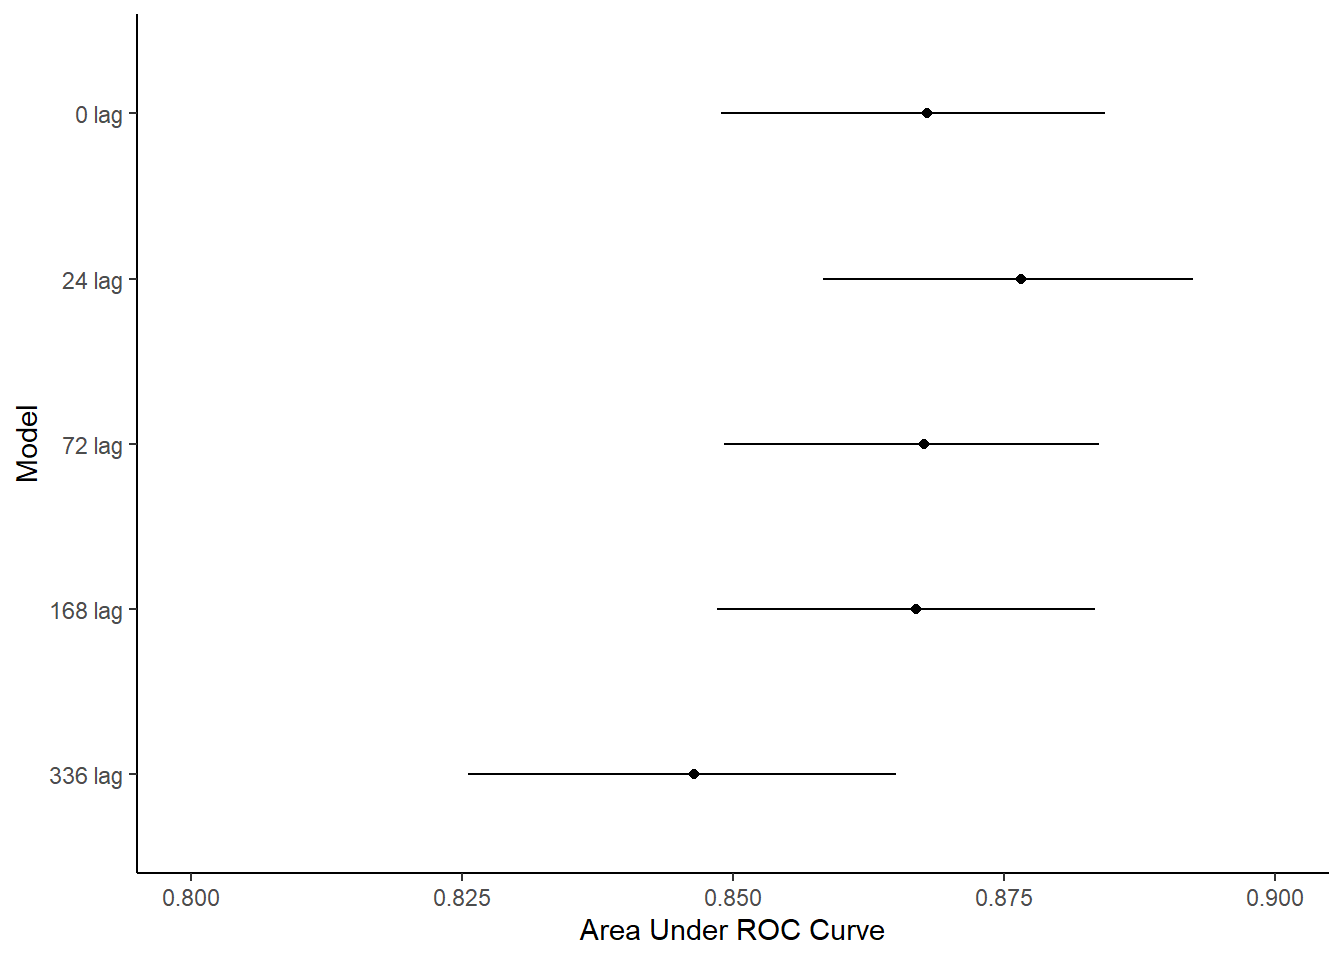

In [ ]:
test_metrics_all_pp_perf |>
  mutate(model = factor(model, levels = c("336 lag", "168 lag", "72 lag", "24 lag", "0 lag" ))) |> 
  ggplot() + 
  geom_point(aes(x = pp_median, y = model), color = "black") +
  geom_segment(mapping = aes(y = model, x = pp_lower, xend = pp_upper),
                data = test_metrics_all_pp_perf) +
  scale_x_continuous("Area Under ROC Curve", limits = c(.80, .90)) +
  ylab("Model") +
  theme_classic() +
  theme(legend.position = "none")

### Model Comparisons

#### Baseline Contrasts

In [ ]:
ci_baseline <- pp |>
  contrast_models(list("lag0", "lag0", "lag0", "lag0"), 
                  list("lag24", "lag72", "lag168", "lag336")) |> 
  summary(size = 0) |> 
  mutate(contrast = factor(contrast, 
                           levels = c("lag0 vs lag24", "lag0 vs lag72", "lag0 vs lag168", 
                                      "lag0 vs lag336"),
                           labels = c("0 vs. 24", "0 vs. 72", 
                                      "0 vs. 168", "0 vs. 336")))

ci_median_baseline <- pp |> 
  contrast_models(list("lag0", "lag0", "lag0", "lag0"), 
                  list("lag24", "lag72", "lag168", "lag336")) |>  
  group_by(contrast) |> 
  summarize(median = quantile(difference, .5)) |> 
  mutate(contrast = factor(contrast, 
                           levels = c("lag0 vs. lag24", "lag0 vs. lag72", "lag0 vs. lag168", 
                                      "lag0 vs. lag336"),
                           labels = c("0 vs. 24", "0 vs. 72", 
                                      "0 vs. 168", "0 vs. 336")))


ci_baseline <- ci_baseline |> 
  left_join(ci_median_baseline, by = c("contrast")) 

ci_baseline |> 
  select(contrast, probability, median, lower, upper) |> 
  arrange(contrast)

# A tibble: 4 × 5
  contrast  probability    median     lower  upper
  <fct>           <dbl>     <dbl>     <dbl>  <dbl>
1 0 vs. 24        0.235 -0.00856  -0.0292   0.0110
2 0 vs. 72        0.513  0.000408 -0.0199   0.0202
3 0 vs. 168       0.528  0.000903 -0.0192   0.0208
4 0 vs. 336       0.948  0.0217   -0.000265 0.0431

The median decrease in auROC for the baseline vs. 24 hour lag model was -0.009 (95% CI=\[-0.029-0.011\]), yielding a non-significant probability of 0.235 that the lagged model had worse performance. The median decrease in auROC for the baseline vs. 72 hour model was 0.000 (95% CI=\[-0.020-0.020\]), yielding a non-significant probability of 0.513 that the lagged model had worse performance. The median increase in auROC for the baseline vs. 168 hour lag model was 0.001 (95% CI=\[-0.019-0.021\]), yielding a non-significant probability of 0.528 that the lagged model had worse performance. The median increase in auROC for the baseline vs. 336 hour lag model was 0.022 (95% CI=\[-0.000-0.043\]), yielding a significant probability of 0.948 that the lagged model had worse performance.

#### Adjacent Contrasts

In [ ]:
ci_lag <- pp |>
  contrast_models(list("lag24", "lag72", "lag168"), 
                  list("lag72", "lag168", "lag336")) |> 
  summary(size = 0) |> 
  mutate(contrast = factor(contrast, 
                           levels = c("lag24 vs lag72", "lag72 vs lag168", 
                                      "lag168 vs lag336"),
                           labels = c("24 vs. 72", "72 vs. 168", "168 vs. 336")))

ci_median_lag <- pp |> 
  contrast_models(list("lag24", "lag72", "lag168"), 
                  list("lag72", "lag168", "lag336")) |>  
  group_by(contrast) |> 
  summarize(median = quantile(difference, .5)) |> 
  mutate(contrast = factor(contrast, 
                           levels = c("lag24 vs. lag72", "lag72 vs. lag168", 
                                      "lag168 vs. lag336"),
                           labels = c("24 vs. 72", "72 vs. 168", "168 vs. 336")))

ci_lag <- ci_lag |> 
  left_join(ci_median_lag, by = c("contrast")) 

ci_lag |> 
  select(contrast, probability, median, lower, upper) |> 
  arrange(contrast)

# A tibble: 3 × 5
  contrast    probability   median    lower  upper
  <fct>             <dbl>    <dbl>    <dbl>  <dbl>
1 24 vs. 72         0.778 0.00889  -0.0106  0.0285
2 72 vs. 168        0.522 0.000755 -0.0189  0.0206
3 168 vs. 336       0.94  0.0206   -0.00117 0.0418

The median decrease in auROC for the 24 hour vs. 72 hour lag model was 0.009 (95% CI=\[-0.011-0.029\]), yielding a non-significant probability of 0.778 that the 72 hour lag model had worse performance than the 24 hour lag model. The median decrease in auROC for the 72 hour vs. 168 hour lag model was 0.001 (95% CI=\[-0.019-0.021\]), yielding a non-significant probability of 0.522 that the 168 hour lag model had worse performance than the 72 hour lag model. The median decrease in auROC for the 168 hour vs. 336 hour lag model was 0.021 (95% CI=\[-0.001-0.042\]), yielding a significant probability of 0.940 that the 336 hour lag model had worse performance than the 168 hour lag model.

### Fairness Benchmarks

Table 2 shows the performance of each model by demographic group. All group comparisons across lags were significantly different. On average there was a median increase in auROC for white participants compared to participants who were not white was 0.226 (95% CI=\[0.156-0.301\]). On average there was a median increase in auROC for male participants compared to female participants was 0.095 (95% CI=\[0.055-0.139\]). On average there was a median increase in auROC for participants above the federal poverty line compared to participants below the federal poverty line was 0.174 (95% CI=\[0.105-0.249\]). On average there was a median increase in auROC for younger participants compared to older participants was 0.071 (95% CI=\[0.021-0.133\]). <!-- Currently averaging across median auROC differences for each model. Also averaging lower and upper CI bounds - is this okay? Should I realculate CI based on average of averages?-->

In [ ]:
pp_dem <- pp_dem |> 
  mutate(lag = factor(lag, levels = c(0, 24, 72, 168, 336), 
                        labels = c("0 lag", "24 lag", "72 lag", "168 lag", "336 lag" )),
         model = factor(model, levels = c("not white", "white",
                                        "female", "male",
                                        "below poverty", "above poverty",
                                        "older", "younger" ))) %>% 
  arrange(model, lag)

pp_dem_all <- pp_dem |> 
  filter(lag == "0 lag") |> 
  mutate(pp_lower = round(pp_lower, 3),
         pp_upper = round(pp_upper, 3),
         ci = str_c(pp_lower,"-",pp_upper)) |>
  select(-c(lag, pp_lower, pp_upper)) |> 
  bind_cols(pp_dem |> 
  filter(lag == "24 lag") |> 
  mutate(pp_lower = round(pp_lower, 3),
         pp_upper = round(pp_upper, 3),
         ci = str_c(pp_lower,"-",pp_upper)) |>
  select(-c(lag, pp_lower, pp_upper, model))) |> 
  bind_cols(pp_dem |> 
  filter(lag == "72 lag") |> 
  mutate(pp_lower = round(pp_lower, 3),
         pp_upper = round(pp_upper, 3),
         ci = str_c(pp_lower,"-",pp_upper)) |>
  select(-c(lag, pp_lower, pp_upper, model))) |> 
  bind_cols(pp_dem |> 
  filter(lag == "168 lag") |> 
  mutate(pp_lower = round(pp_lower, 3),
         pp_upper = round(pp_upper, 3),
         ci = str_c(pp_lower,"-",pp_upper)) |>
  select(-c(lag, pp_lower, pp_upper, model))) |> 
  bind_cols(pp_dem |> 
  filter(lag == "336 lag") |> 
  mutate(pp_lower = round(pp_lower, 3),
         pp_upper = round(pp_upper, 3),
         ci = str_c(pp_lower,"-",pp_upper)) |>
  select(-c(lag, pp_lower, pp_upper, model))) 

New names:
New names:
New names:
New names:
• `pp_median` -> `pp_median...2`
• `ci` -> `ci...3`
• `pp_median` -> `pp_median...4`
• `ci` -> `ci...5`

Warning in kable_styling(kbl(pp_dem_all, format = "simple", booktabs = TRUE, :
Please specify format in kable. kableExtra can customize either HTML or LaTeX
outputs. See https://haozhu233.github.io/kableExtra/ for details.

Warning in add_header_above(kable_styling(kbl(pp_dem_all, format = "simple", :
Please specify format in kable. kableExtra can customize either HTML or LaTeX
outputs. See https://haozhu233.github.io/kableExtra/ for details.

Warning in pack_rows(add_header_above(kable_styling(kbl(pp_dem_all, format =
"simple", : Please specify format in kable. kableExtra can customize either
HTML or LaTeX outputs. See https://haozhu233.github.io/kableExtra/ for details.

Warning in pack_rows(pack_rows(add_header_above(kable_styling(kbl(pp_dem_all, :
Please specify format in kable. kableExtra can customize either HTML or LaTeX
outputs. See https://haozhu233.github.io/kableExtra/ for details.

Warning in
pack_rows(pack_rows(pack_rows(add_header_above(kable_styling(kbl(pp_dem_all, :
Please specify format in kable. kableExtra can customize either HTML or LaTeX
outputs. See https://haozhu233.github.io/kableExtra/ for details.

Warning in
pack_rows(pack_rows(pack_rows(pack_rows(add_header_above(kable_styling(kbl(pp_dem_all,
: Please specify format in kable. kableExtra can customize either HTML or LaTeX
outputs. See https://haozhu233.github.io/kableExtra/ for details.

  Group             median PP for auROC Bayesian CI     median PP for auROC Bayesian CI     median PP for auROC Bayesian CI     median PP for auROC Bayesian CI     median PP for auROC Bayesian CI
  --------------- --------------------- ------------- --------------------- ------------- --------------------- ------------- --------------------- ------------- --------------------- -------------
  not white                       0.660 0.573-0.737                   0.657 0.565-0.735                   0.648 0.559-0.729                   0.647 0.552-0.731                   0.564 0.458-0.663
  white                           0.875 0.835-0.905                   0.883 0.846-0.912                   0.876 0.838-0.908                   0.866 0.823-0.899                   0.849 0.795-0.889
  female                          0.810 0.755-0.854                   0.823 0.771-0.866                   0.809 0.756-0.854                   0.792 0.735-0.84                    0.768 0.698-0.825
  male                            0.904 0.872-0.929                   0.907 0.876-0.93                    0.905 0.874-0.929                   0.902 0.869-0.927                   0.888 0.848-0.919
  below poverty                   0.706 0.616-0.78                    0.712 0.621-0.787                   0.697 0.61-0.776                    0.649 0.552-0.736                   0.635 0.529-0.727
  above poverty                   0.871 0.832-0.903                   0.877 0.838-0.907                   0.871 0.832-0.902                   0.863 0.82-0.898                    0.849 0.794-0.889
  older                           0.813 0.754-0.863                   0.817 0.756-0.867                   0.799 0.737-0.852                   0.787 0.713-0.847                   0.784 0.704-0.848
  younger                         0.878 0.84-0.909                    0.885 0.85-0.916                    0.878 0.841-0.908                   0.867 0.824-0.901                   0.856 0.807-0.893


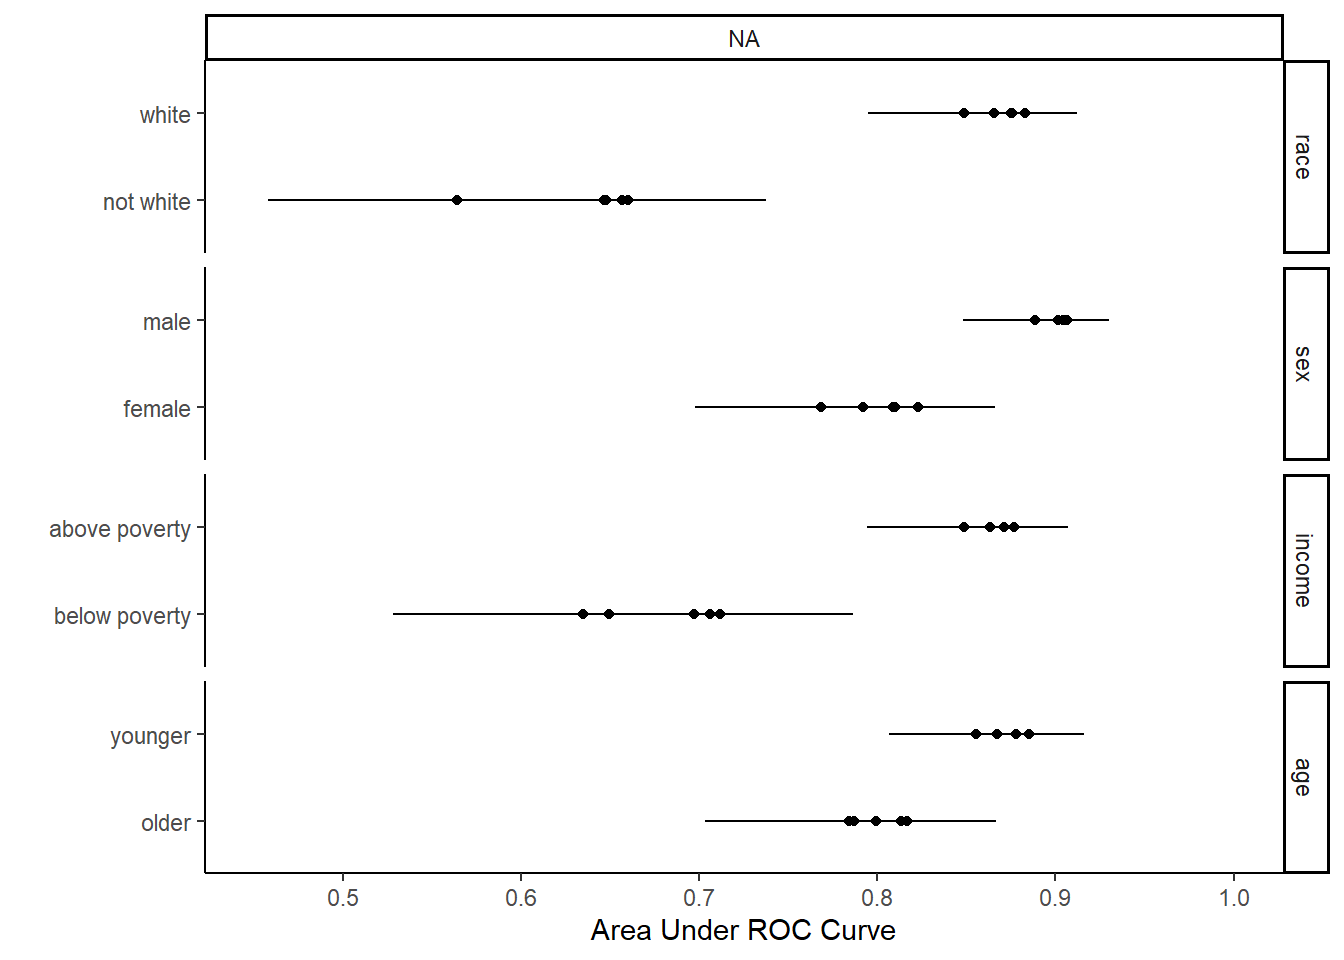

In [ ]:
pp_dem |>
  mutate(lag = factor(lag, levels = c(0, 24, 72, 168, 336), 
                        labels = c("0 lag", "24 lag", "72 lag", "168 lag", "336 lag" )),
         model = factor(model, levels = c("not white", "white",
                                        "female", "male",
                                        "below poverty", "above poverty",
                                        "older", "younger" )),
         comparison = factor(model,
                             levels = c("not white", "white",
                                        "female", "male",
                                        "below poverty", "above poverty",
                                        "older", "younger" ),
                             labels = c("race", "race",
                                        "sex", "sex",
                                        "income", "income",
                                        "age", "age"))) |> 
  ggplot() + 
  geom_point(aes(x = pp_median, y = model), color = "black") +
  geom_segment(mapping = aes(y = model, x = pp_lower, xend = pp_upper),
                data = pp_dem |> 
                 mutate(lag = factor(lag, levels = c(0, 24, 72, 168, 336), 
                        labels = c("0 lag", "24 lag", "72 lag", "168 lag", "336 lag" )),
                        comparison = factor(model,
                             levels = c("not white", "white",
                                        "female", "male",
                                        "below poverty", "above poverty",
                                        "older", "younger" ),
                             labels = c("race", "race",
                                        "sex", "sex",
                                        "income", "income",
                                        "age", "age")))) +
  facet_grid(comparison~lag, scales = "free_y") +
  scale_x_continuous("Area Under ROC Curve", limits = c(.45, 1), breaks = c(.5, .6, .7, .8, .9, 1.0)) +
  ylab("") +
  theme_classic() +
  theme(legend.position = "none")

### Feature Importance

## Discussion

-   Improving model performance for unprivileged classes. Considering other important classes for SUD, such as geographic location, Improving diversity of training data

## References